# Word Vectors

En este trabajo, utilizaremos **embeddings** para resolver un problema de clasificación de texto. Los embeddings, representaciones distribuidas y vectoriales de elementos, son un concepto muy común en el mundo del deep learning. Los **word vectors** que hemos visto en clase son una representación en forma de embedding de las palabras.

Para realizar este trabajo y sacarle el máximo partido, se recomienda ver los siguientes vídeos de clase:

*   Clasificación de texto con Word Vectors.
*   Análisis de overfitting con un modelo bag of words.
*   Clasificación de texto con RNN

Vamos a utilizar el dataset **"Reuters newswire topics classification"**, disponible desde Keras de manera similar al dataset de IMDB ([ver documentación](https://keras.io/datasets/#reuters-newswire-topics-classification)).

---

Se pide:

Entrenar un modelo **utilizando embeddings** que consiga un **65% de accuracy en test (55% si usamos RNNs)**, mostrando el entrenamiento y el resultado final.
 
Tenemos varias opciones para entrenar modelos con embeddings. El alumno puede explorar más de una pero es suficiente con conseguir un modelo que alcance la accuracy requerida:

*   Utilizar una **media de embeddings** al estilo de lo visto en el vídeo *Clasificación de texto con Word Vectors*
*   Utilizar una **CNN** sobre una secuencia de word vectors. Aquí necesitamos cambiar un poco la idea de convolución para actuar sobre sequencias de vectores. Keras incluye una [Convolución en 1D](https://keras.io/layers/convolutional/#conv1d) que puede ser utilizada en este caso, con un ejemplo de uso en la documentación. Una forma de hacer funcionar este esquema sería utilizar la convolución en 1D + max pooling.
*  Utilizar una **RNN** sobre una secuencia de word vectors, al estilo de lo visto en el vídeo *Clasificación de texto con RNN*. Para este problema es un poco complicado conseguir un buen modelo con RNNs, y además es más difícil experimentar ya que las redes recurrentes son modelos lentos de entrenar. Por eso, es suficiente con alcanzar un 55% de accuracy si optamos por utilizar un modelo de este estilo. Un buen consejo es emplear una red recurrente bidireccional como se ve en el vídeo *Clasificación de texto con RNN*.



---

Dos hiperparámetros importantes a elegir en el modelo son la **longitud de las secuencias de texto** y el **tamaño del vocabulario** para los embeddings. Podéis experimentar con ambos, o utilizar los mismos que se usan en los vídeos. Nótese que, al cortar todas las secuencias para que tengan el mismo tamaño, podríamos estar perdiendo mucho texto si elegimos un tamaño de secuencia demasiado pequeño. Igualmente, si las hacemos muy largas necesitaremos más tiempo para entrenar nuestros modelos. Una buena idea consiste en explorar los datos para ver cómo suelen ser de largos los textos y encontrar un buen trade-off para el tamaño de al secuencia.



---

Los embeddings que hemos visto en los vídeos se entrenan junto al modelo.  Una técnica frecuente es inicializar estos embeddings con word-vectors pre-entrenados en un gran corpus de texto, como hemos visto en clase. Esto puede ayudar ya que nuestro modelo empieza con unos embeddings que ya encapsulan significado. Si bien no es necesario para esta práctica, podéis ver cómo usar esta técnica [en el siguiente tutorial](https://blog.keras.io/using-pre-trained-word-embeddings-in-a-keras-model.html).




## Word Vectors

**Actividad 3**

**Alumno:** _Carlos David Álvaro Yunta_

En esta práctica se pretende entrenar un clasificador de noticias que sea capaz de identificar el tema de una noticia dado su contenido.

Para ello se van a entrenar y comparar tres modelos distintos:

- *Embedding* con `Dense` (fully connected)
- *Embedding* con `CNN`
- *Embedding* con `RNN`

Se usará el catálago disponible en Keras de *Reuters* que contiene textos asociados a noticias para un total de `46` temas distintos.

### Funciones auxiliares

A continuación se implementan una serie de funciones de apoyo que se usarán en el resto de la práctica para facilitar la lectura del informe.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import keras

class Decodificador:
    '''
    Clase para decodificar textos a partir de su índice
    '''

    def __init__(self, indice:{str:int}):
        '''
        Constructor de la clase para decodificar textos

        Argumentos
            indice: {str:int} -> Diccionario cuyas claves son las cadenas de texto
                                 y los valores su índice asociado
        '''
        # Almacena el índice y lo adapta para los tokens extra
        indice = {k: v + Decodificador.index_from() for k,v in indice.items()}
        indice['<PAD>'] = Decodificador.index_padding()
        indice['<START>'] = Decodificador.index_start()
        indice['<UNK>'] = Decodificador.index_unknown()
        indice['<UNUSED>'] = Decodificador.index_from()
        self._indice = indice
    
        # Índice reverso para poder convertir textos
        # en su forma codificada a texto legible por humanos
        self._indice_reverso = {v:k for k,v in self._indice.items()}

    def decodificar(self, texto:[int]):
        '''
        Decodifica el texto proporcionado

        Argumentos
            texto: [int] -> Array de elementos codificados del texto a decodificar
        
        Devuelve:
            Cadena de texto con el texto decodificado
        '''
        return ' '.join([self._indice_reverso.get(idx, '?') for idx in texto])

    @staticmethod
    def index_padding():
        '''
        Devuelve:
            Índice asociado a padding
        '''
        return 0

    @staticmethod
    def index_start():
        '''
        Devuelve:
            Índice asociado al comienzo del texto
        '''
        return 1
    
    @staticmethod
    def index_unknown():
        '''
        Devuelve:
            Índice asociado a un elemento que no está registrado en el índice
        '''
        return 2
    
    @staticmethod
    def index_from():
        '''
        Devuelve:
            Número entero con el índice asignado a la primera palabra real
        '''
        return 3

def buscar_longitud_optima(textos:[int],
                           minima_longitud_permitida:int = 20,
                           minima_frecuencia_permitida:float = 1e-03):
    '''
    Función para obtener la longitud más frecuente de la lista de textos proporcionada

    Argumentos
        textos: [int] -> Lista de textos a analizar para obtener la longitud más frecuente
        minima_longitud_permitida: int -> Mínima longitud que se tendrá en cuenta,
                                          las longitudes inferiores se descartan
        minima_frecuencia_permitida: float -> Mínima frecuencia que se tendrá en cuenta,
                                              las frecuencias inferiores se descartan

    Devuelve:
        La longitud más frecuente y su frecuencia asociada
    '''
    frec_long_textos = dict()
    for texto in textos:
        longitud = len(texto)
        if longitud not in frec_long_textos:
            frec_long_textos[longitud] = 0
        frec_long_textos[longitud] += 1

    # Normalización de frecuencias
    for longitud in frec_long_textos.keys():
        frec_long_textos[longitud] /= len(textos)

    # Filtros
    # Longitudes mínimas
    dict_tmp = frec_long_textos.copy()
    for longitud in dict_tmp.keys():
        if longitud < minima_longitud_permitida:
            del frec_long_textos[longitud]
    
    # Frecuencias bajas
    dict_tmp = frec_long_textos.copy()
    for longitud, frecuencia in dict_tmp.items():
        if frecuencia < minima_frecuencia_permitida:
            del frec_long_textos[longitud]

    # Cálculo de la frecuencia óptima
    longitud_optima = 0
    max_frec = 0
    for longitud, frecuencia in frec_long_textos.items():
        if frecuencia > max_frec:
            max_frec = frecuencia
            longitud_optima = longitud

    # Se ordenan las frecuencias para su representación
    frec_long_textos = {k:frec_long_textos[k] for k in sorted(frec_long_textos)}

    # Representación del gráfico de longitudes y frecuencias
    plt.figure(figsize=(11, 5))
    
    plt.axvline(x=longitud_optima, label=f'Longitud óptima: {longitud_optima} ({max_frec*100:.2f}%)',
                color='black', linestyle='dashed', linewidth=1)
    plt.plot(list(frec_long_textos.keys()), list(frec_long_textos.values()))

    plt.title("Gráfico de frecuencias de longitudes", fontsize=14)
    plt.xlabel("Longitudes (número de palabras)", fontsize=12)
    plt.ylabel("Frecuencias", fontsize=12)
    plt.legend(loc="upper right")
    plt.show()

    return longitud_optima, max_frec

def truncar_conjunto(textos:[int], longitud:int, index_padding:int=Decodificador.index_padding()):
    '''
    Función para truncar una lista de textos según la longitud especificada

    Argumentos
        textos: [int] -> Lista con los textos que se quieren truncar
        longitud: int -> Longitud a la que se quieren truncar los textos
        index_padding: int -> Índice asociado al padding
    
    Devuelve:
        La lista de textos truncada a la longitud indicada
    '''
    return keras.preprocessing.sequence.pad_sequences(textos,
                                                      maxlen=longitud,
                                                      padding='post',
                                                      value=index_padding)

def representar_historia(history:keras.callbacks.History):
    '''
    Método para representar la historia de entrenamiento de un modelo de keras

    Argumentos
        history: keras.callbacks.History -> Historia devuelta al entrenar el modelo
    '''
    
    df = pd.DataFrame(history.history)
    df.insert(loc=0, column='epoch', value=np.arange(0, df.shape[0]))    
    
    plt.figure(figsize=(11, 5))
    
    plt.plot(df['epoch'], df['loss'], label="Training loss")
    plt.plot(df['epoch'], df['val_loss'], label="Validation loss")
    plt.plot(df['epoch'], df['acc'], label="Training accuracy")
    plt.plot(df['epoch'], df['val_acc'], label="Validation accuracy")
    
    best_epoch=df['val_loss'].idxmin()
    plt.axvline(x=best_epoch, label=f'Best epoch: #{best_epoch}',
                color='black', linestyle='dashed', linewidth=1)
    
    plt.title("Training Loss and Accuracy", fontsize=14)
    plt.xlabel("Epoch #", fontsize=12)
    plt.ylabel("Loss / Accuracy", fontsize=12)
    plt.legend(loc="upper right")

    plt.show()

def compilar_entrenar_validar_modelo(model,
                                     X_train, y_train,
                                     X_test, y_test,
                                     epochs:int = 40,
                                     batch_size:int = 128,
                                     validation_split:float = 0.2,
                                     verbose:bool = True,
                                     summary:bool = True):
    
    # Resumen de la arquitectura del modelo
    if summary:
        model.summary()

    # Compilación del modelo
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    # Callback para detener el entrenamiento si los resultados comienzan a empeorar en validación
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=int(epochs * 0.25),
        restore_best_weights=True,
        verbose=verbose)

    # Entrenamiento del modelo
    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_split=validation_split,
                        callbacks=[ early_stopping ],
                        verbose=verbose)

    # Validación del modelo entrenado
    representar_historia(history)

    loss, accuracy = model.evaluate(X_test, y_test, batch_size=batch_size)
    print(f'- loss: {loss * 100:.2f}%'.format())
    print(f'- accuracy: {accuracy * 100:.2f}%')

    return history, loss, accuracy

### Carga y análisis del catálogo

Ahora se procede a cargar el catálogo de *Reuters* y a estudiar por qué elementos está compuesto.

In [2]:
# Carga del conjunto de datos a partir del dataset de reuters de Keras
import numpy as np
from keras.datasets import reuters

# Número de palabras con mayor frecuencia a recuperar del conjunto de datos
numero_palabras = 15000

(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=numero_palabras,
                                                         index_from=Decodificador.index_from(),
                                                         start_char=Decodificador.index_start(),
                                                         skip_top=0,
                                                         maxlen=None,
                                                         oov_char=2)

print(f'->> Número de registros para entrenamiento: {len(x_train)}')
print(f'->> Número de registros de validación: {len(x_test)}')

# Diccionario para la decodificación de los elementos
indice = reuters.get_word_index()
if not numero_palabras:
    numero_palabras=len(indice)+1
print(f'->> Número de palabras distintas en el catálogo: {numero_palabras}')

# Número de temas en el catálogo
numero_temas=max(y_train.max(), y_test.max()) + 1
print(f'->> Número de temas en el catálogo: {numero_temas}')

# Ejemplo de uno de los textos del catálogo
decodificador = Decodificador(indice)
print(f'->> Ejemplo decodificado: {decodificador.decodificar(x_train[0])}')

->> Número de registros para entrenamiento: 8982
->> Número de registros de validación: 2246
->> Número de palabras distintas en el catálogo: 15000
->> Número de temas en el catálogo: 46
->> Ejemplo decodificado: <START> <UNK> <UNK> said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3


Una vez cargado el conjunto de datos de trabajo y separados en entrenamiento y test se va a estudiar dentro del conjunto de entrenamiento cuál es la longitud más frecuente de los textos.

Esta longitud se usará para truncar aquellos textos que sean más largos y para añadir elementos de *padding* a aquellos que sean más cortos.

De este modo se consigue homogeneizar el conjunto de entrenamiento y establecer un estándar para los modelos utilizados.

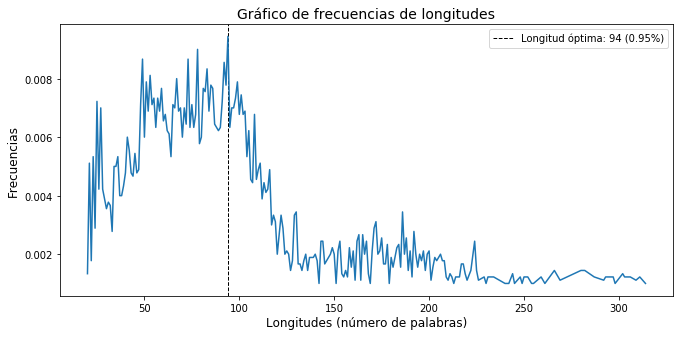

In [3]:
longitud_optima, frecuencia = buscar_longitud_optima(x_train)

### Preparación de los datos de entrenamiento

Para poder manejar los datos en los modelos es necesario prepararlos.

Las modificaciones que se harán son las siguientes:

- *Textos de entrenamiento y test*: Se truncarán a la `longitud_optima` calculada anteriormente para que todos los textos tengan la mis longitud. Se usa la función definida al comienzo: `truncar_conjunto`.
- *Categorías de los textos de entrenamiento y test*: Se modificarán para que dejen de ser variables numéricas indicando el número de la categoría para que pasen a ser categorías binarias. Se usa la función de keras `to_categorical`.

In [4]:
from keras.utils import to_categorical

# Se homogeniza la longitud de los textos
x_train = truncar_conjunto(x_train, longitud_optima)
x_test = truncar_conjunto(x_test, longitud_optima)

# Conversión de las variables categóricas para que keras pueda manejarlas
y_train = to_categorical(y_train, num_classes=numero_temas)
y_test = to_categorical(y_test, num_classes=numero_temas)

### Entrenamiento de los modelos

Ahora se van a entrenar los tres modelos sugeridos en el enunciado de la práctica, pero antes se van a definir algunos parámetros comunes al entrenamiento de todos los modelos.

In [5]:
# Dimensión de los word embedding
output_dim = longitud_optima // 2

#### Modelo con media de embeddings

Este modelo se va a componer de una capa de tipo `Embedding` que entrenará los *word vectors* o *word embeddings*. Posteriormete se aplicará una capa de promedio, `GlobalAveragePooling1D` y se usarán dos capas de tipo `Dense` para que el modelo aprenda.

Como función de activación de la capa final se usará la función `softmax` dado que se trata de un problema de clasificación.

Posteriormente se usará la función `compilar_entrenar_validar_modelo` que será común en el entrenamiento de los tres modelos y que hace las siguientes acciones sobre el modelo:

- Muestra un resumen de la arquitectura del modelo
- Entrena el modelo
- Muestra un gráfico con la historia del entrenamiento del modelo
- Evalúa el modelo entrenado con los datos reservados para test

Además se emplea una condición de `EarlyStopping` para que el modelo no siga entrenando si el conjunto de validación del entrenamiento empieza a obtener peores resultados de `val_loss`.

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_4 (Embedding)      (None, 94, 47)            705000    
_________________________________________________________________
global_average_pooling1d_2 ( (None, 47)                0         
_________________________________________________________________
dense_6 (Dense)              (None, 47)                2256      
_________________________________________________________________
dense_7 (Dense)              (None, 46)                2208      
Total params: 709,464
Trainable params: 709,464
Non-trainable params: 0
_________________________________________________________________


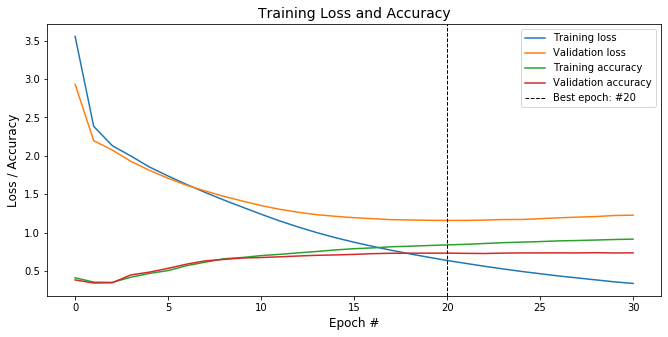

2246/2246 [==============================] - 0s 17us/step
- loss: 123.45%
- accuracy: 71.06%


In [6]:
from keras.models import Sequential
from keras.layers import Dense, GlobalAveragePooling1D
from keras.layers.embeddings import Embedding

emb_model = Sequential()

emb_model.add(Embedding(numero_palabras, output_dim, input_length=longitud_optima))
emb_model.add(GlobalAveragePooling1D())
emb_model.add(Dense(output_dim, activation='relu'))
emb_model.add(Dense(numero_temas, activation='softmax'))

emb_hist, emb_loss, emb_acc = compilar_entrenar_validar_modelo(emb_model,
                                                               x_train, y_train,
                                                               x_test, y_test,
                                                               verbose=False)

#### Modelo con CNN

Ahora se entrenará un modelo que hará uso de una *red neuronal convolucional*.

De nuevo como primera capa se usa `Embedding` para el entrenamiento de los *word embeddings*, seguida de una capa convolucional de una dimensión, `Conv1D` y de otra capa `MaxPooling1D` para reducir la dimensionalidad. A continuación se usa una capa `Flatten` para *aplanar* los tensores de datos y se usan dos capas *fully-connected*  para que el modelo siga aprendiendo.

Igual que en el caso anterior, la función de activación de la capa de salida es `softmax` y tiene tantas neuronas como temas identificados.

Cabe destacar, que tras muchos intentos de mejorar la precisión del modelo, la configuración que se presenta a continuación es la que mejor resultados a generado de manera estable, rondando siempre entorno al 65% de *accuracy* en el proceso de validación del modelo con los datos reservados para test.

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_5 (Embedding)      (None, 94, 47)            705000    
_________________________________________________________________
conv1d_2 (Conv1D)            (None, 92, 128)           18176     
_________________________________________________________________
max_pooling1d_2 (MaxPooling1 (None, 30, 128)           0         
_________________________________________________________________
flatten_2 (Flatten)          (None, 3840)              0         
_________________________________________________________________
dense_8 (Dense)              (None, 512)               1966592   
_________________________________________________________________
dense_9 (Dense)              (None, 46)                23598     
Total params: 2,713,366
Trainable params: 2,713,366
Non-trainable params: 0
____________________________________________

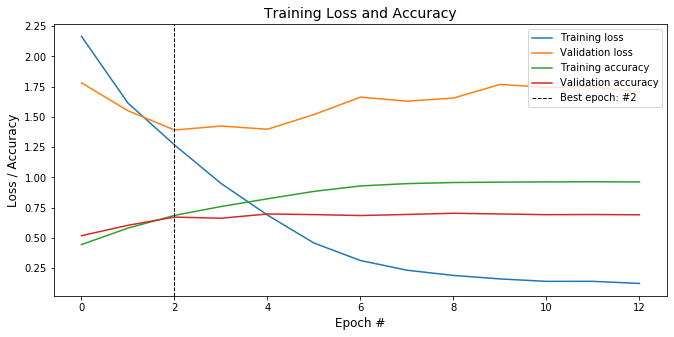

2246/2246 [==============================] - 0s 35us/step
- loss: 145.42%
- accuracy: 65.14%


In [7]:
from keras.layers import Conv1D, MaxPooling1D, Flatten

cnn_model = Sequential()

cnn_model.add(Embedding(numero_palabras, output_dim, input_length=longitud_optima))
cnn_model.add(Conv1D(128, 3, activation='relu'))
cnn_model.add(MaxPooling1D(3))
cnn_model.add(Flatten())
cnn_model.add(Dense(512, activation='relu'))
cnn_model.add(Dense(numero_temas, activation='softmax'))

cnn_hist, cnn_loss, xnn_acc = compilar_entrenar_validar_modelo(cnn_model,
                                                               x_train, y_train,
                                                               x_test, y_test,
                                                               verbose=False)

#### Modelo con LSTM

En este caso se usa una *red neuronal recurrente (RNN)* de tipo `LSTM` para el modelo.

Este modelo es el más sencillo en cuanto a su composición ya que cuenta con una capa de tipo `Embedding`, otra `LSTM` y finalmente la capa de salida de tipo `Dense`.

A continuación se muestra el entrenamiento y sus resultados.



Model: "sequential_9"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_9 (Embedding)      (None, 94, 47)            705000    
_________________________________________________________________
lstm_5 (LSTM)                (None, 64)                28672     
_________________________________________________________________
dense_13 (Dense)             (None, 46)                2990      
Total params: 736,662
Trainable params: 736,662
Non-trainable params: 0
_________________________________________________________________
Train on 7185 samples, validate on 1797 samples
Epoch 1/40
7185/7185 [==============================] - 16s 2ms/step - loss: 2.8876 - acc: 0.3431 - val_loss: 2.3849 - val_acc: 0.3450
Epoch 2/40
7185/7185 [==============================] - 14s 2ms/step - loss: 2.3298 - acc: 0.3692 - val_loss: 2.2037 - val_acc: 0.4190
Epoch 3/40
7185/7185 [==============================] - 14s 

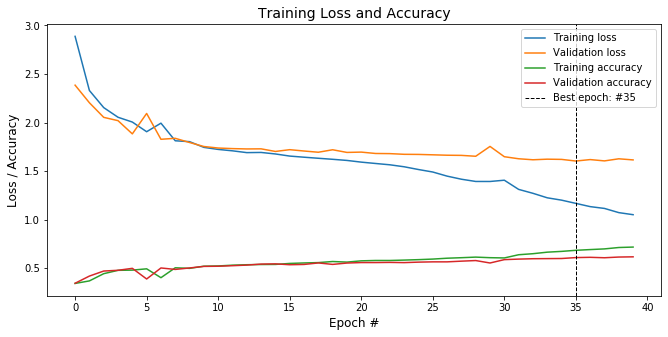

2246/2246 [==============================] - 2s 692us/step
- loss: 174.75%
- accuracy: 60.28%


In [8]:
# Entrenamiento del clasificador con LSTM (RNN)
from keras.layers import LSTM

lstm_model = Sequential()

lstm_model.add(Embedding(numero_palabras, output_dim, input_length=longitud_optima))
lstm_model.add(LSTM(units=64, dropout=0.2, recurrent_dropout=0.2))
lstm_model.add(Dense(numero_temas, activation='softmax'))

lstm_hist, lstm_loss, lstm_acc = compilar_entrenar_validar_modelo(lstm_model,
                                                                  x_train, y_train,
                                                                  x_test, y_test)

### Conclusiones

A primera vista, lo que más llama la atención es que ninguno de los tres modelos consigue una *accuracy* por encima del 80% lo que indica que no son modelos muy fiables.

No obstante, si se comparan entre ellos, hay un modelo que claramente es mejor que los otros dos, este es el modelo de *medias de embedding* que ha obtenido un resultado entorno al 70%.

El modelo entrenado con `LSTM` requiere mucho más tiempo de cálculo para el entrenamiento y también para la predicción que los otros dos. Esto, junto con el resultado obtenido para la *accuracy* con el conjunto de test entorno al 60%, que ha sido el peor de entre los tres modelos, lo convierte en el peor.

El modelo de tipo *CNN* no ha dado resultados muy malos, pero no son mejores que los del modelo de *medias de embedding* lo que lo deja en segunda posición, con una *accuracy* alrededor del 65%. Sin embargo, una cosa a destacar de este modelo, es que su entrenamiento es muy rápido ya que alcanza su mejor resultado en una etapa muy temprana del mismo, alrededor de la tercera época, lo que puede hacer que este modelo sea determinante en ocasiones en las que los tiempos de entrenamiento marquen la diferencia.